In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url_test = "https://raw.githubusercontent.com/nararyabhuana/Pintar-Bersama-EdTech-/refs/heads/main/data_siswa_pintar_bersama_Test.csv"
df_test = pd.read_csv(url_test)

url_train = "https://raw.githubusercontent.com/nararyabhuana/Pintar-Bersama-EdTech-/refs/heads/main/data_siswa_pintar_bersama_Training.csv"
df_train = pd.read_csv(url_train)

### Data Test

In [ ]:
df_test.head()

,id_siswa,durasi_klik,waktu_modul,ulang_video,skor_kuis,login_frekuensi
0,S-1501,2736.20,88.74,7.0,86.99,3
1,S-1502,2676.88,54.96,5.0,56.33,5
2,S-1503,2594.08,-118.33,6.0,59.00,5
3,S-1504,2644.54,123.19,4.0,73.27,6
4,S-1505,2747.95,128.37,7.0,34.60,5


### Drop kolom yang tidak perlu

In [ ]:
df_test.drop(columns=['id_siswa'], inplace=True)

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   durasi_klik      500 non-null    float64
 1   waktu_modul      500 non-null    float64
 2   ulang_video      463 non-null    float64
 3   skor_kuis        500 non-null    float64
 4   login_frekuensi  500 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 19.7 KB


In [ ]:
df_test.describe(include="all")

,durasi_klik,waktu_modul,ulang_video,skor_kuis,login_frekuensi
count,5.000000e+02,500.000000,463.000000,500.000000,500.000000
mean,2.047872e+05,55.136380,2.978402,67.036580,3.912000
std,6.272026e+05,45.428963,2.612733,22.107737,1.847995
min,8.282000e+01,-138.680000,0.000000,10.000000,0.000000
25%,1.007490e+03,30.000000,1.000000,51.522500,3.000000
50%,1.941700e+03,54.985000,2.000000,68.960000,4.000000
75%,2.795738e+03,88.665000,5.000000,85.697500,5.000000
max,3.423370e+06,141.550000,10.000000,100.000000,8.000000


### Missing value

In [ ]:
df_test.isnull().sum()

,0
durasi_klik,0
waktu_modul,0
ulang_video,37
skor_kuis,0
login_frekuensi,0


In [ ]:
df_test['ulang_video'].fillna(0, inplace=True)

/tmp/ipykernel_8794/2931053151.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['ulang_video'].fillna(0, inplace=True)


In [ ]:
df_test.isnull().sum()

,0
durasi_klik,0
waktu_modul,0
ulang_video,0
skor_kuis,0
login_frekuensi,0


### Ubah ulang_video ke int

In [ ]:
df_test['ulang_video'] = df_test['ulang_video'].astype(int)

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   durasi_klik      500 non-null    float64
 1   waktu_modul      500 non-null    float64
 2   ulang_video      500 non-null    int64  
 3   skor_kuis        500 non-null    float64
 4   login_frekuensi  500 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 19.7 KB


### Menghilangkan data kolom waktu_modul yang kurang dari 0 ( alasan dihilangkan karena tidak mungkin jam belajar dibawah 0 )

In [ ]:
df_test = df_test[df_test['waktu_modul'] >= 0]

### Check Duplicate

In [ ]:
df_test.duplicated().sum()

np.int64(0)

### Check Outliers

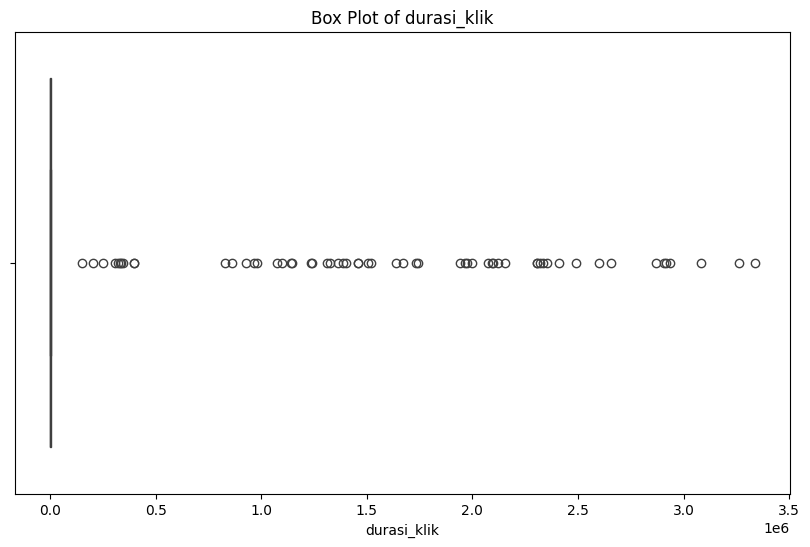

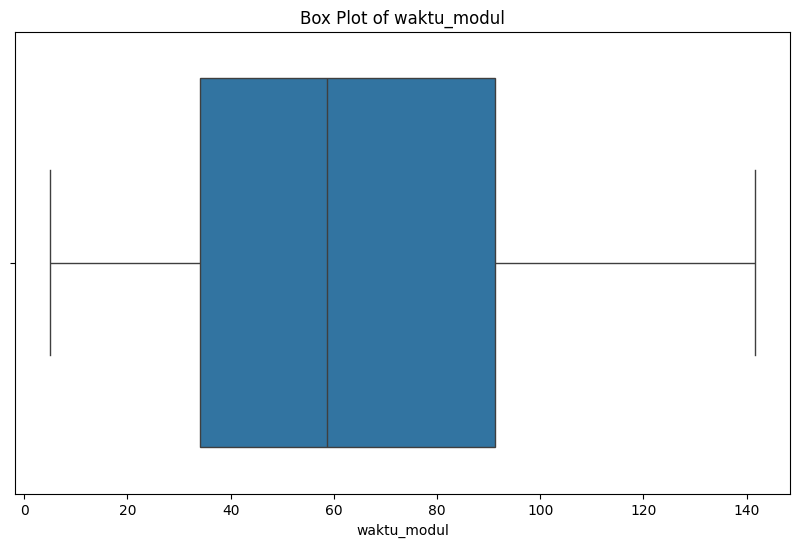

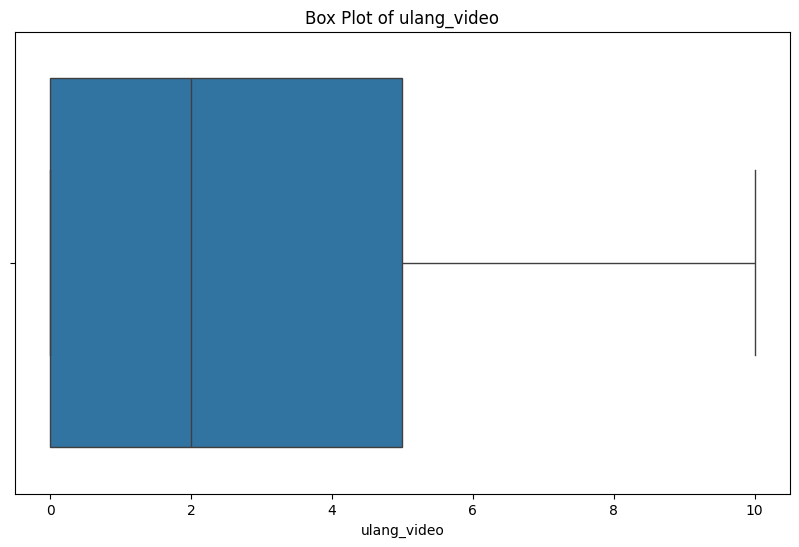

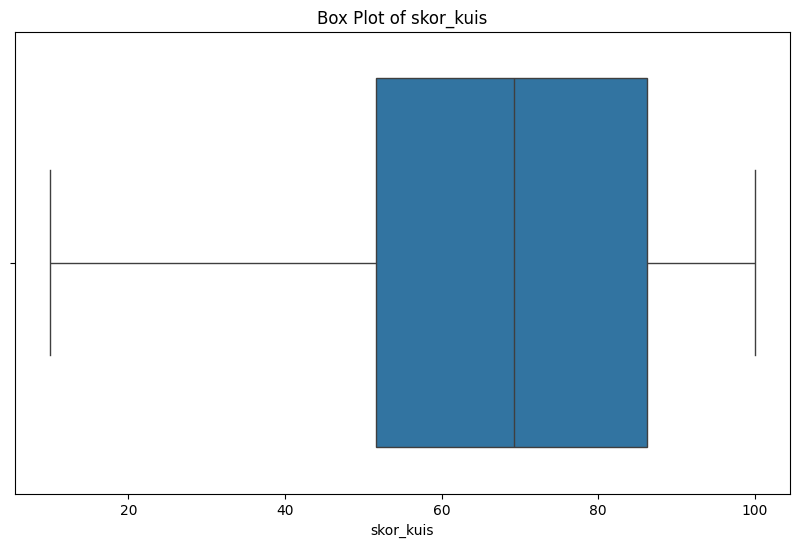

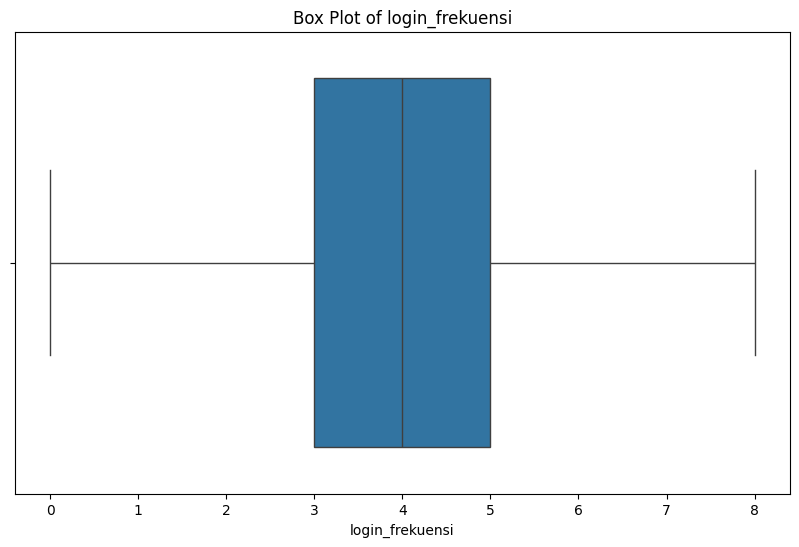

In [ ]:
for feature in df_test.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_test[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

### Data Train

In [ ]:
df_train.head()

,id_siswa,durasi_klik,waktu_modul,ulang_video,skor_kuis,login_frekuensi
0,S-0001,358.89,15.08,1.0,16.78,1
1,S-0002,1731.27,83.70,2.0,36.04,6
2,S-0003,321.16,13.88,0.0,14.86,3
3,S-0004,221.01,16.92,1.0,73.79,1
4,S-0005,1603.48,48.91,1.0,100.00,4


### Drop kolom yang tidak perlu

In [ ]:
df_train.drop(columns=['id_siswa'], inplace=True)

In [ ]:
df_train.describe()

,durasi_klik,waktu_modul,ulang_video,skor_kuis,login_frekuensi
count,1.500000e+03,1500.000000,1400.000000,1500.000000,1500.000000
mean,1.603182e+05,51.387773,2.689286,64.058940,3.557333
std,5.707224e+05,43.177382,2.563816,23.028862,1.922805
min,5.000000e+01,-132.890000,0.000000,10.000000,0.000000
25%,4.598775e+02,17.855000,1.000000,46.912500,2.000000
50%,1.632790e+03,48.990000,2.000000,65.180000,4.000000
75%,2.680727e+03,85.992500,5.000000,83.552500,5.000000
max,3.808261e+06,174.590000,11.000000,100.000000,8.000000


### Missing value

In [ ]:
df_train.isnull().sum()

,0
durasi_klik,0
waktu_modul,0
ulang_video,100
skor_kuis,0
login_frekuensi,0


In [ ]:
df_train['ulang_video'].fillna(0, inplace=True)

/tmp/ipykernel_8794/2282237201.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['ulang_video'].fillna(0, inplace=True)


In [ ]:
df_train.isnull().sum()

,0
durasi_klik,0
waktu_modul,0
ulang_video,0
skor_kuis,0
login_frekuensi,0


### Ubah ulang_video ke int

In [ ]:
df_train['ulang_video'] = df_train['ulang_video'].astype(int)

### Menghilangkan data kolom waktu_modul yang kurang dari 0 ( alasan dihilangkan karena tidak mungkin jam belajar dibawah 0 )

In [ ]:
df_train.describe(include="all")

,durasi_klik,waktu_modul,ulang_video,skor_kuis,login_frekuensi
count,1.500000e+03,1500.000000,1500.000000,1500.000000,1500.000000
mean,1.603182e+05,51.387773,2.510000,64.058940,3.557333
std,5.707224e+05,43.177382,2.566117,23.028862,1.922805
min,5.000000e+01,-132.890000,0.000000,10.000000,0.000000
25%,4.598775e+02,17.855000,0.000000,46.912500,2.000000
50%,1.632790e+03,48.990000,1.000000,65.180000,4.000000
75%,2.680727e+03,85.992500,4.000000,83.552500,5.000000
max,3.808261e+06,174.590000,11.000000,100.000000,8.000000


In [ ]:
df_train = df_train[df_train['waktu_modul'] >= 0]

### Check Duplicate

In [ ]:
df_test.duplicated().sum()

np.int64(0)

### Check Outliers

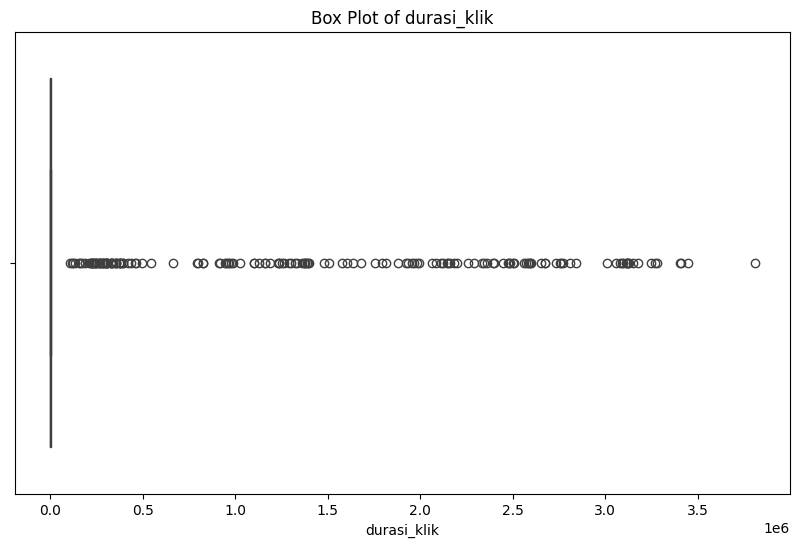

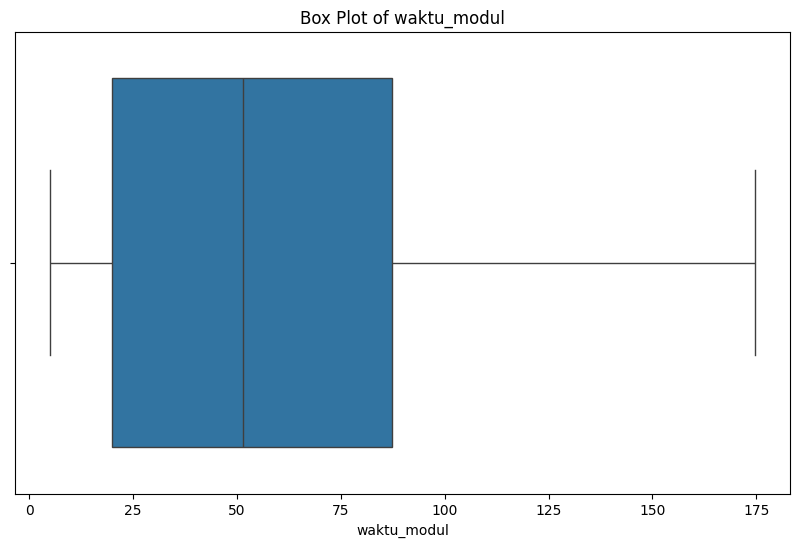

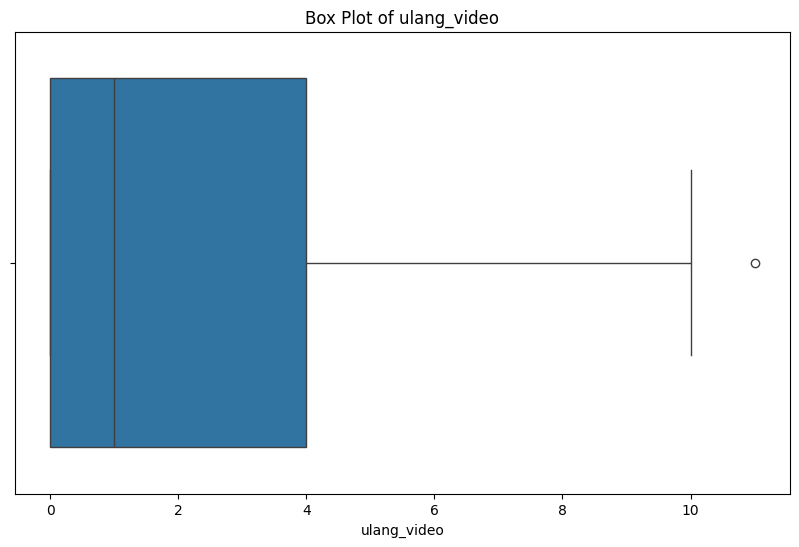

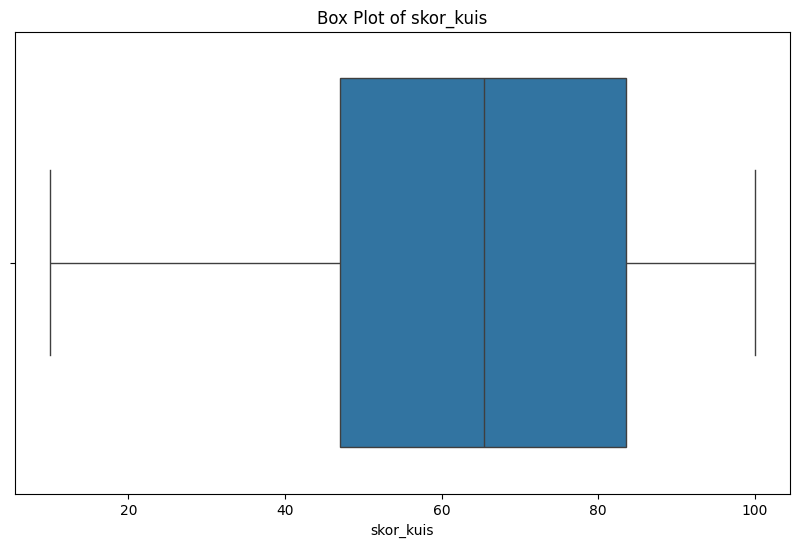

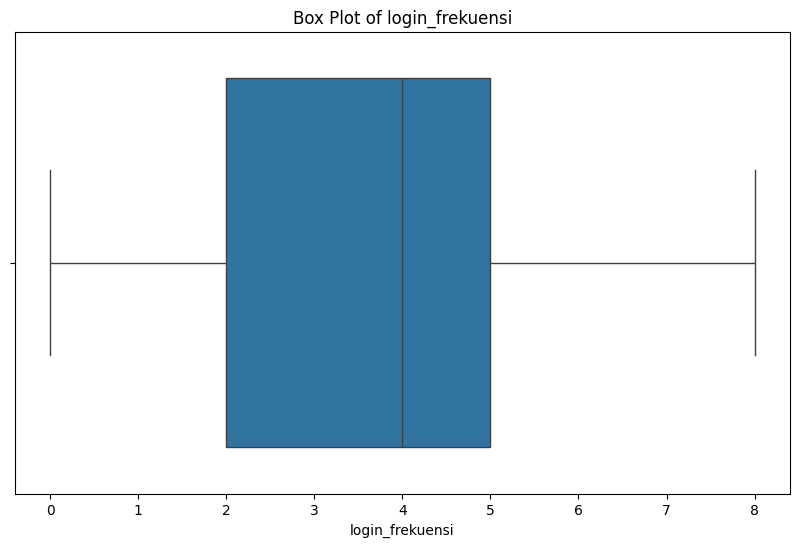

In [ ]:
for feature in df_train.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_train[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

Scatter Plot

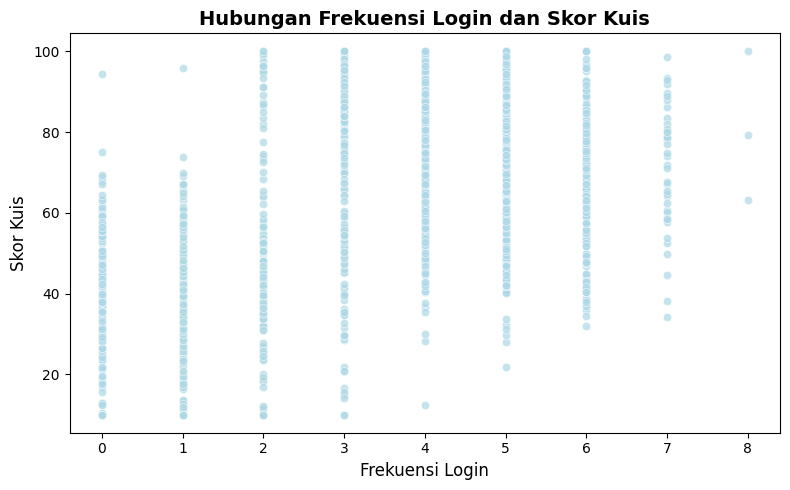

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_train, x='login_frekuensi', y='skor_kuis', color='lightblue', alpha=0.7)
plt.title('Hubungan Frekuensi Login dan Skor Kuis', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi Login', fontsize=12)
plt.ylabel('Skor Kuis', fontsize=12)
plt.tight_layout()
plt.show()

Histogram Distribusi

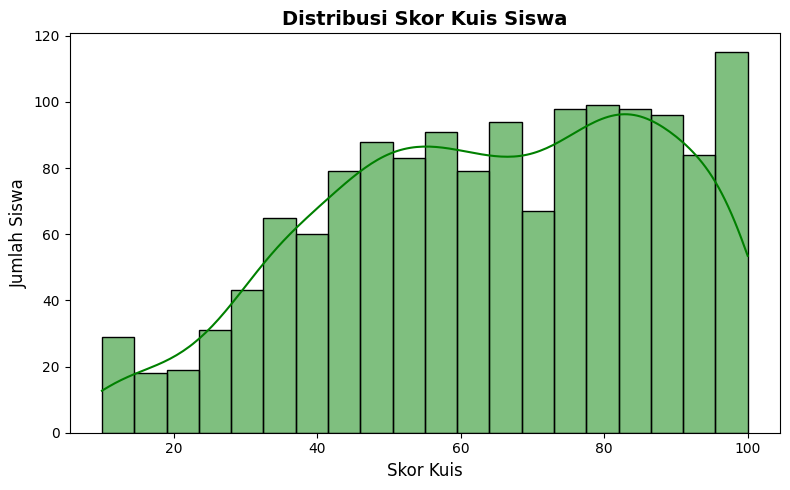

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_train['skor_kuis'], bins=20, kde=True, color='green')
plt.title('Distribusi Skor Kuis Siswa', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kuis', fontsize=12)
plt.ylabel('Jumlah Siswa', fontsize=12)
plt.tight_layout()
plt.show()

Heatmap

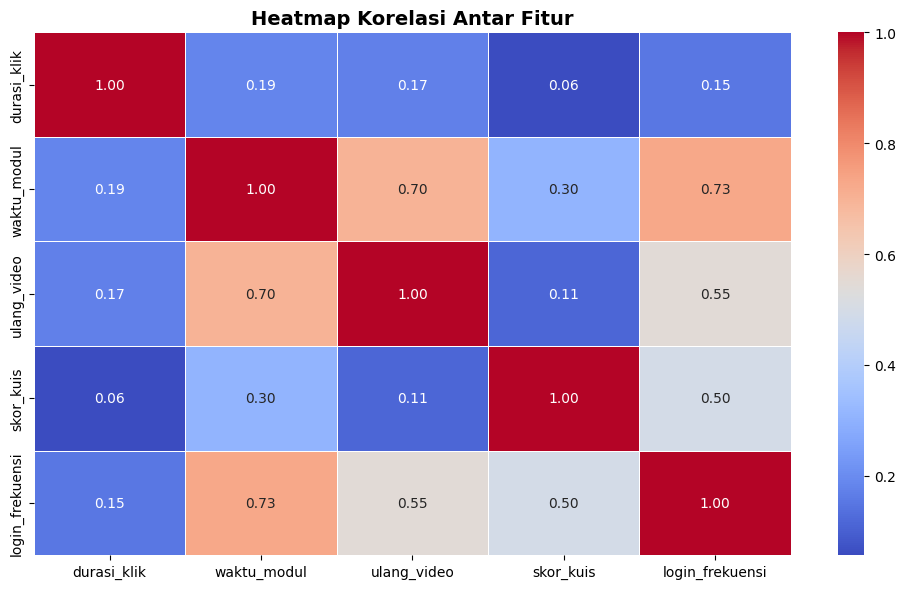

In [ ]:
plt.figure(figsize=(10, 6))
corr_matrix = df_train.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Kesimpulan**

**Scatter plot:** Dari scatter plot, siswa yang lebih sering login ke platform cenderung mendapatkan skor kuis yang lebih tinggi.

**Distribusi Skor Kuis:** Dari grafik histogram, sebaran nilai siswa cukup merata, dengan lebih banyak siswa yang nilainya berada di rentang atas. Artinya, sebagian besar siswa sudah cukup memahami materi yang diberikan.

**Heatmap:** Berdasarkan heatmap, siswa yang sering login cenderung lebih sering mengulang video, dan keduanya sama-sama berhubungan positif dengan skor kuis. Di antara semua fitur, frekuensi login punya hubungan paling kuat dengan nilai akhir siswa.